# 04 – The Showdown: Evaluation Arena

**Operation Ledger-Mind: The Financial Intelligence**

In [1]:
# Setup
import sys
import os
from pathlib import Path
from dotenv import load_dotenv
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
from rouge_score import rouge_scorer
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('weaviate').setLevel(logging.ERROR)
logging.getLogger('sentence_transformers').setLevel(logging.ERROR)

sys.path.append(str(Path.cwd().parent))
load_dotenv()

from src.services.llm_services import load_config, get_llm
config = load_config("../src/config/config.yaml")
judge_llm = get_llm(config)
print("✅ Judge LLM ready")

✅ Judge LLM ready


In [2]:
# Load test data
test_file = Path(config['artifacts_root']) / "data_factory" / "golden_test_set.jsonl"

test_data = []
with open(test_file) as f:
    for line in f:
        test_data.append(json.loads(line))

eval_samples = test_data[:50]  # Use subset
print(f"✅ Loaded {len(eval_samples)} test samples")

✅ Loaded 50 test samples


In [3]:
from inference_utils import query_intern, query_librarian

# Placeholder functions if models not loaded
try:
    query_intern("test")
    print("✅ query_intern available")
except:
    def query_intern(q):
        return "[Run Notebook 02 first]"
    print("⚠️  query_intern not found - placeholder used")

try:
    query_librarian("test")
    print("✅ query_librarian available")
except:
    def query_librarian(q, return_sources=False):
        if return_sources:
            return {'answer': "[Run Notebook 03 first]", 'context': ''}
        return "[Run Notebook 03 first]"
    print("⚠️  query_librarian not found - placeholder used")

Loading The Intern (Fine-Tuned Model)...
Loading from: artifacts/finetuned_model/final_adapters
Loading base model...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

⏳ Loading fine-tuned adapters...


Python(27188) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


✅ Model loaded!
✅ query_intern() ready!
Loading The Librarian (RAG System)...


...

Python(27201) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
{"build_git_commit":"73b12b15b4","build_go_version":"go1.26.4","build_image_tag":"HEAD","build_wv_version":"1.38.0","level":"warning","log_level_env":"","msg":"log level not recognized, defaulting to info","time":"2026-06-13T20:48:20+05:30"}
{"action":"startup","build_git_commit":"73b12b15b4","build_go_version":"go1.26.4","build_image_tag":"HEAD","build_wv_version":"1.38.0","level":"info","msg":"Feature flag LD integration disabled: could not locate WEAVIATE_LD_API_KEY env variable","time":"2026-06-13T20:48:20+05:30"}
{"action":"startup","build_git_commit":"73b12b15b4","build_go_version":"go1.26.4","build_image_tag":"HEAD","build_wv_version":"1.38.0","default_vectorizer_module":"none","level":"info","msg":"the default vectorizer modules is set to \"none\", as a result all new schema classes without an explicit vectorizer setting, will use this vectorizer","time":"2026-06-13T20:48:20+05:30"

✅ Connected to collection: UberFinancials
⏳ Loading cross-encoder reranker...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Reranker loaded
✅ query_librarian() ready!
✅ query_intern available
✅ query_librarian available


In [4]:
# Evaluation functions
def calculate_rouge_l(prediction, reference):
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    return scorer.score(reference, prediction)['rougeL'].fmeasure

def llm_as_judge(question, generated, reference, context, judge_llm, category="accuracy"):
    context_block = f"\nRetrieved context:\n{context[:500]}" if context else ""

    prompt = f"""You are evaluating a financial QA system on Uber's 2024 Annual Report.

Score the generated answer from 1 to 5:
5 - Completely accurate, matches reference
4 - Mostly accurate, minor omissions
3 - Partially correct, key facts missing
2 - Mostly wrong or vague
1 - Completely wrong or hallucinated
{context_block}

Question: {question}
Reference answer: {reference}
Generated answer: {generated}

Reply with ONLY a single digit (1-5):"""

    import re
    response = judge_llm.invoke(prompt)
    text = response.content
    match = re.search(r'([1-5])', text)
    score = int(match.group(1)) if match else 3

    return {'score': score, 'reasoning': text[:200]}

print("✅ Evaluation functions ready")

✅ Evaluation functions ready


In [5]:
# Run evaluation
from tqdm import tqdm

intern_results = []
librarian_results = []

for sample in tqdm(eval_samples, desc="Evaluating"):
    question = sample['question']
    reference = sample['answer']
    
    # Evaluate Intern
    start = time.time()
    intern_answer = query_intern(question)
    intern_latency = (time.time() - start) * 1000
    intern_judge = llm_as_judge(question, intern_answer, reference, "", judge_llm)

    intern_results.append({
        'question':    question,
        'generated':   intern_answer,
        'reference':   reference,
        'rouge_l':     calculate_rouge_l(intern_answer, reference),
        'judge_score': intern_judge['score'],
        'latency_ms':  intern_latency
    })
    
    # Evaluate Librarian
    start = time.time()
    lib_result = query_librarian(question, return_sources=True)
    lib_latency = (time.time() - start) * 1000
    lib_judge = llm_as_judge(question, lib_result['answer'], reference, lib_result['context'], judge_llm)

    librarian_results.append({
        'question':    question,
        'generated':   lib_result['answer'],
        'reference':   reference,
        'rouge_l':     calculate_rouge_l(lib_result['answer'], reference),
        'judge_score': lib_judge['score'],
        'latency_ms':  lib_latency
    })

print("✅ Evaluation complete")

Evaluating: 100%|██████████| 50/50 [17:08<00:00, 20.57s/it]

✅ Evaluation complete


In [6]:
print(query_librarian("What was Uber's revenue in 2024?"))

According to the provided context from Uber's 2024 Annual Report, Uber's revenue in 2024 was $43,978 million.


In [7]:
# Aggregate results
df_intern = pd.DataFrame(intern_results)
df_librarian = pd.DataFrame(librarian_results)

comparison = pd.DataFrame([
    {
        'Model':            'The Intern (Fine-tuned)',
        'Avg ROUGE-L':      round(df_intern['rouge_l'].mean(), 3),
        'Avg Judge Score':  round(df_intern['judge_score'].mean(), 2),
        'Avg Latency (ms)': round(df_intern['latency_ms'].mean(), 0)
    },
    {
        'Model':            'The Librarian (RAG)',
        'Avg ROUGE-L':      round(df_librarian['rouge_l'].mean(), 3),
        'Avg Judge Score':  round(df_librarian['judge_score'].mean(), 2),
        'Avg Latency (ms)': round(df_librarian['latency_ms'].mean(), 0)
    }
])

print("\n" + "="*80)
print("EVALUATION RESULTS")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)


EVALUATION RESULTS
                  Model  Avg ROUGE-L  Avg Judge Score  Avg Latency (ms)
The Intern (Fine-tuned)        0.247             3.14            2876.0
    The Librarian (RAG)        0.363             4.22           13931.0


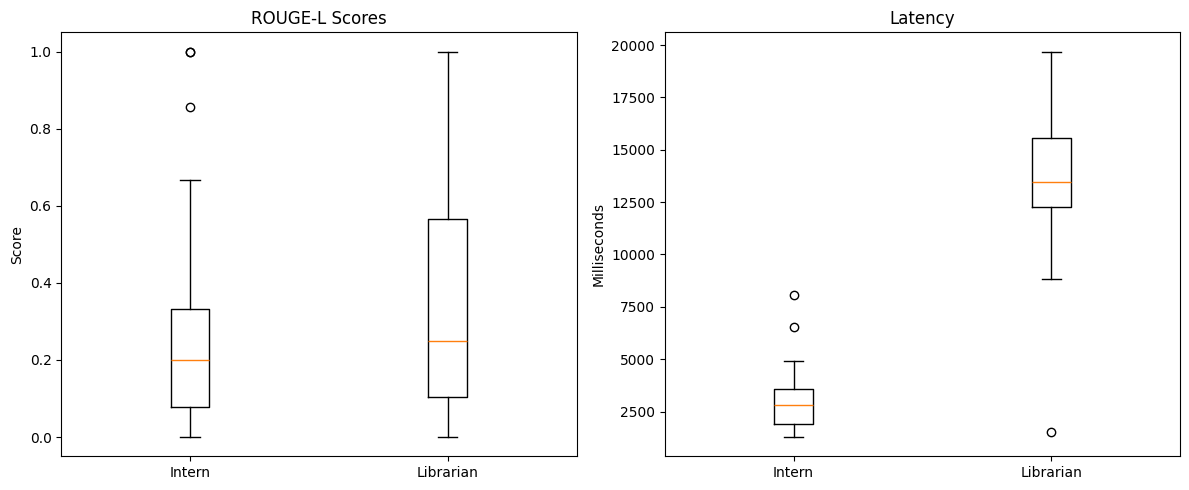


✅ Saved evaluation_results.png


In [8]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROUGE-L
axes[0].boxplot([df_intern['rouge_l'], df_librarian['rouge_l']], 
                tick_labels=['Intern', 'Librarian'])
axes[0].set_title('ROUGE-L Scores')
axes[0].set_ylabel('Score')

# Latency
axes[1].boxplot([df_intern['latency_ms'], df_librarian['latency_ms']], 
                tick_labels=['Intern', 'Librarian'])
axes[1].set_title('Latency')
axes[1].set_ylabel('Milliseconds')

plt.tight_layout()
plt.savefig('figures/evaluation_results.png', dpi=300)
plt.show()

print("\n✅ Saved evaluation_results.png")

In [9]:
# Cost analysis
daily_users = 500
queries_per_user = 10
monthly_queries = daily_users * queries_per_user * 30

# Intern (GPU)
gpu_cost_per_hour = 0.526  # g4dn.xlarge
intern_monthly_cost = gpu_cost_per_hour * 24 * 30

# Librarian (API + Weaviate)
weaviate_cost = 25
llm_cost_per_query = 0.0001
lib_monthly_cost = weaviate_cost + (llm_cost_per_query * monthly_queries)

print(f"\nMonthly Cost Analysis")
print(f"="*80)
print(f"Monthly queries: {monthly_queries:,}")
print(f"\nThe Intern (GPU):     ${intern_monthly_cost:,.2f}/month")
print(f"The Librarian (API):  ${lib_monthly_cost:,.2f}/month")

if intern_monthly_cost < lib_monthly_cost:
    savings = lib_monthly_cost - intern_monthly_cost
    print(f"\n✅ Intern is cheaper by ${savings:,.2f}/month ({savings/lib_monthly_cost*100:.1f}% savings)")
else:
    savings = intern_monthly_cost - lib_monthly_cost
    print(f"\n✅ Librarian is cheaper by ${savings:,.2f}/month ({savings/intern_monthly_cost*100:.1f}% savings)")

print("="*80)
print("\n✅ The Showdown is complete!")


💰 Monthly Cost Analysis
Monthly queries: 150,000

The Intern (GPU):     $378.72/month
The Librarian (API):  $40.00/month

✅ Librarian is cheaper by $338.72/month (89.4% savings)

✅ The Showdown is complete!
